Using Colab cache for faster access to the 'toronto-emotional-speech-set-tess' dataset.
Path to dataset files: /kaggle/input/toronto-emotional-speech-set-tess


/tmp/ipykernel_8032/715300177.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


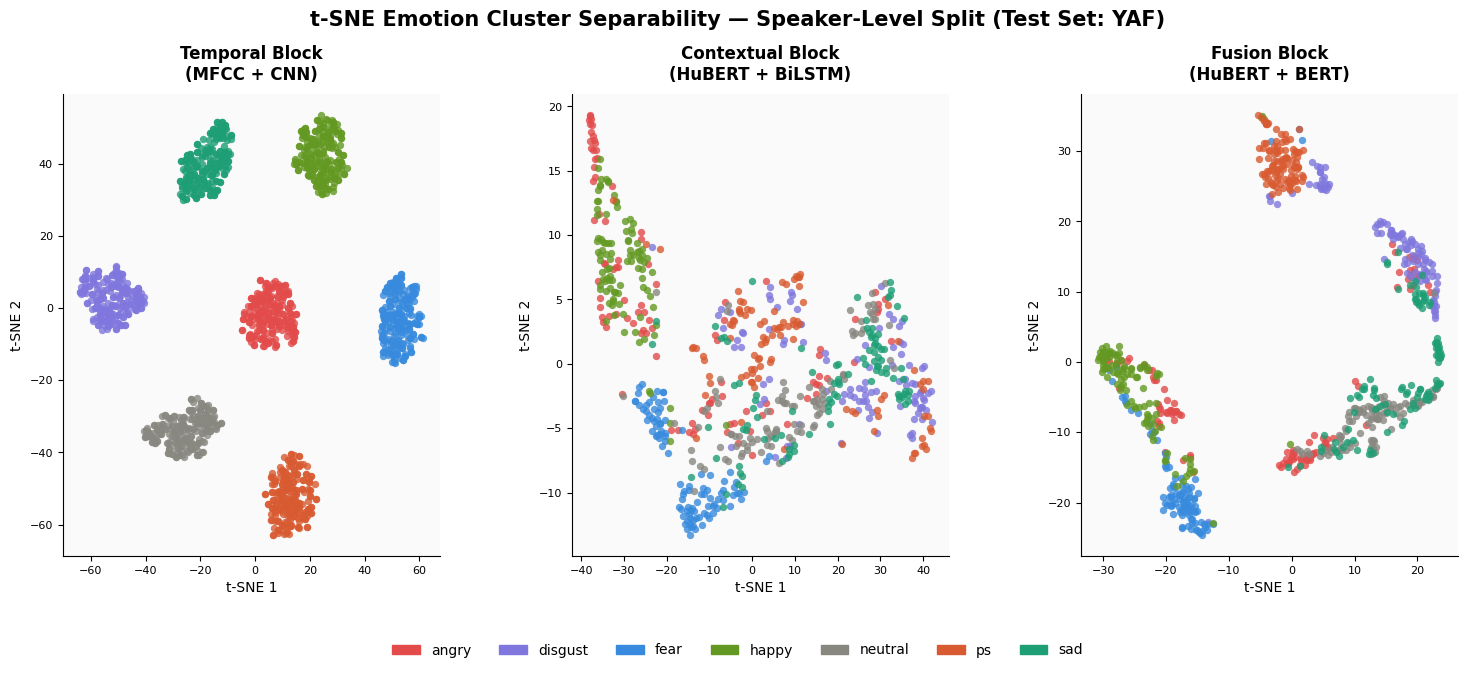

Saved: tsne_speaker_split.png


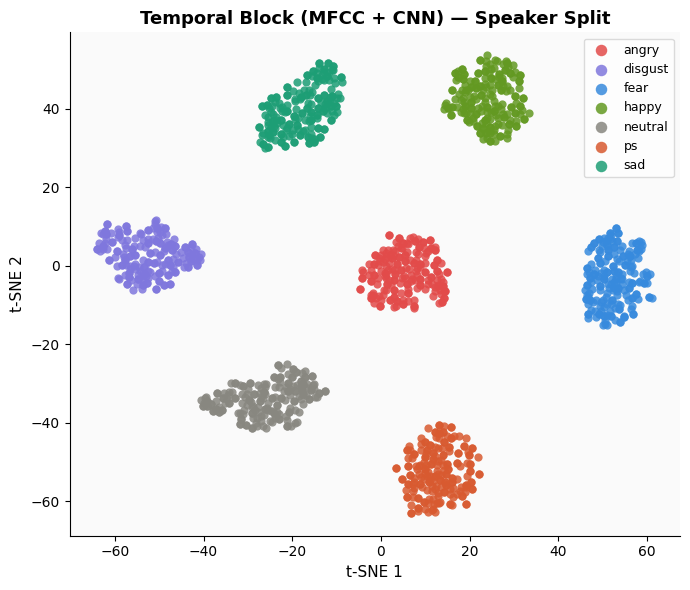

Saved: /content/drive/MyDrive/tess_speaker_tsne/tsne_cnn_hires.png


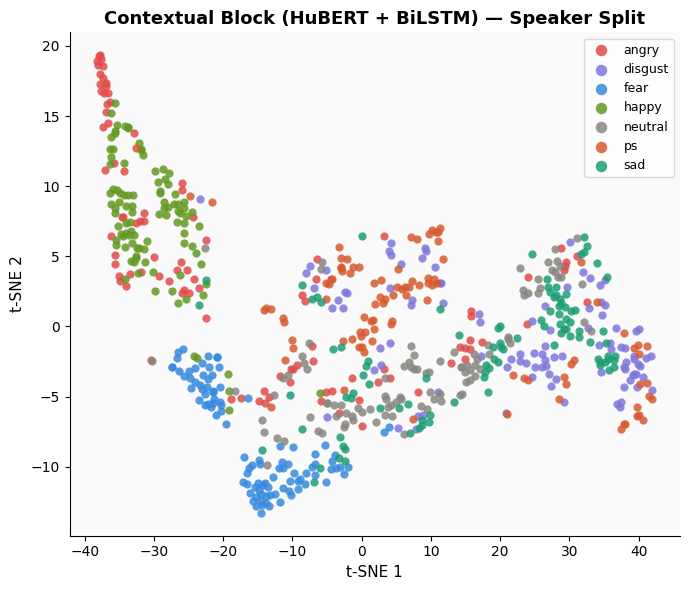

Saved: /content/drive/MyDrive/tess_speaker_tsne/tsne_hub_hires.png


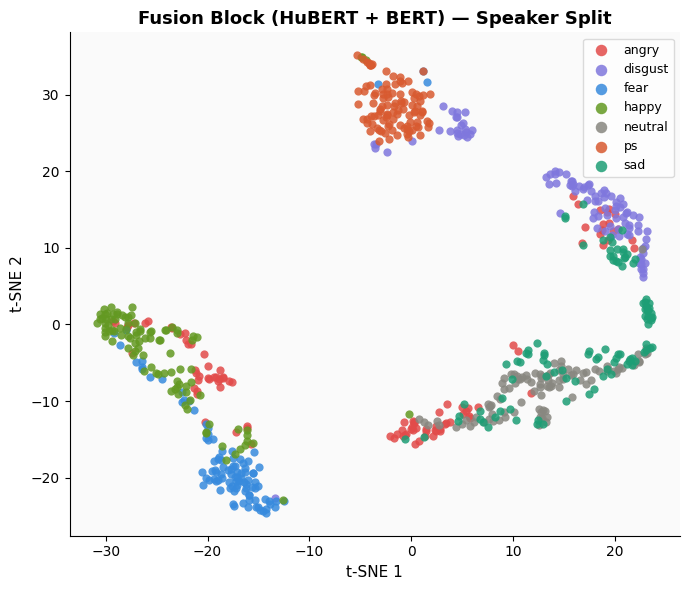

Saved: /content/drive/MyDrive/tess_speaker_tsne/tsne_fus_hires.png


In [2]:
import kagglehub
path = kagglehub.dataset_download("ejlok1/toronto-emotional-speech-set-tess")
print("Path to dataset files:", path)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

tsne_dir      = "/content/drive/MyDrive/tess_speaker_tsne"
emotion_names = ['angry','disgust','fear','happy','neutral','ps','sad']
COLORS        = ['#E24B4A','#7F77DD','#378ADD','#639922','#888780','#D85A30','#1D9E75']

configs = [
    ("tsne_reps_cnn", "labels_cnn",  "Temporal Block\n(MFCC + CNN)"),
    ("tsne_reps_hub", "labels_hub",  "Contextual Block\n(HuBERT + BiLSTM)"),
    ("tsne_reps_fus", "labels_fus",  "Fusion Block\n(HuBERT + BERT)"),
]

fig = plt.figure(figsize=(18, 6))
fig.suptitle(
    "t-SNE Emotion Cluster Separability — Speaker-Level Split (Test Set: YAF)",
    fontsize=15, fontweight='bold', y=1.02
)
gs = GridSpec(1, 3, figure=fig, wspace=0.35)

for idx, (tsne_name, lbl_name, title) in enumerate(configs):
    embedding = np.load(f"{tsne_dir}/{tsne_name}.npy")
    labels    = np.load(f"{tsne_dir}/{lbl_name}.npy")

    ax = fig.add_subplot(gs[0, idx])

    for emo_idx, (emo, col) in enumerate(zip(emotion_names, COLORS)):
        mask = labels == emo_idx
        ax.scatter(
            embedding[mask, 0], embedding[mask, 1],
            c=col, s=28, alpha=0.80, linewidths=0,
            label=emo, zorder=2
        )

    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('t-SNE 1', fontsize=10)
    ax.set_ylabel('t-SNE 2', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor('#FAFAFA')

# Shared legend below all plots
handles = [mpatches.Patch(color=c, label=e) for c, e in zip(COLORS, emotion_names)]
fig.legend(
    handles=handles, loc='lower center', ncol=7,
    fontsize=10, frameon=False,
    bbox_to_anchor=(0.5, -0.08)
)

plt.tight_layout()
plt.savefig(f"{tsne_dir}/tsne_speaker_split.png", dpi=180, bbox_inches='tight')
plt.show()
print("Saved: tsne_speaker_split.png")

#Individual high-res plots
for idx, (tsne_name, lbl_name, title) in enumerate(configs):
    embedding = np.load(f"{tsne_dir}/{tsne_name}.npy")
    labels    = np.load(f"{tsne_dir}/{lbl_name}.npy")

    fig2, ax2 = plt.subplots(figsize=(7, 6))
    for emo_idx, (emo, col) in enumerate(zip(emotion_names, COLORS)):
        mask = labels == emo_idx
        ax2.scatter(embedding[mask,0], embedding[mask,1],
                    c=col, s=35, alpha=0.85, linewidths=0, label=emo, zorder=2)

    ax2.set_title(f"{title.replace(chr(10),' ')} — Speaker Split", fontsize=13, fontweight='bold')
    ax2.set_xlabel('t-SNE 1', fontsize=11)
    ax2.set_ylabel('t-SNE 2', fontsize=11)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.set_facecolor('#FAFAFA')
    ax2.legend(loc='best', fontsize=9, framealpha=0.7, markerscale=1.4)

    fname = f"{tsne_dir}/tsne_{['cnn','hub','fus'][idx]}_hires.png"
    plt.tight_layout()
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")